In [4]:
quiet_library <- function(...){suppressPackageStartupMessages(library(...))}
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(tidyr)
quiet_library(data.table)
quiet_library(Seurat)
quiet_library(DoubletFinder)
#quiet_library(SeuratDisk)
quiet_library(ggplot2)
quiet_library(glue)
quiet_library(hise)
quiet_library(H5weaver)
#quiet_library(eulerr)
quiet_library(gridExtra)

options(repr.matrix.max.cols=150, repr.matrix.max.rows=250, mc.cores = 1, future.globals.maxSize = 8000 * 1024^2)
fig.size <- function (height, width) {
    options(repr.plot.height = height, repr.plot.width = width)
}
set.seed(123)

In [5]:
wd <- "/home/workspace/IFN" 
setwd(wd)

In [ ]:
'%ni%' <- Negate(`%in%`)

## Pull Data from HISE

In [14]:
file_uuid <- list("31fc4e3a-df66-4745-9c33-c36cb2ba84be", "9fbd917e-b35e-47ac-9994-818d5e0888e0", "4179438c-231b-4590-9dfe-f149ba2d919a", "fdf23c91-e934-4e6a-a6a9-9c540840ceb4", "5235c648-5db6-44ac-bfb8-5b4f301551b8", "4722f3e3-c665-4c55-86b3-3dadeff9ceae", "5f593ffa-0102-4781-b649-dbdd6c17c4ac", "7817c535-c87f-401c-a0d8-3c64a6557bb5", "69230e73-094f-4d12-8ccf-b54f1b3743a1", "6bd259a6-3fa0-41d2-b1c2-8eab8977c809", "860a7b97-7665-4ba5-9765-309a35dfc268", "a3408187-2f18-49af-a41c-a7fab470ae3e", "263aaf2f-c977-4f44-a33a-324c5f4052ef", "a6269e3d-5a7d-4fda-9745-ae35889afe55", "c98016d3-ff86-4a8e-9c5a-5e4e196038ce", "1355c32a-3a77-4ca9-a2a8-2fe5ec4e0590", "4960d859-3d54-4cbf-a367-49eac397d2c2", "8b66ffbe-953d-452b-886e-c8597f7db155", "fdc9373f-d25e-4b1e-9f6d-a6151797d1dc", "e3044953-eb4d-414c-8f49-a34182830452", "08745d12-b221-43eb-90e6-d8dec0b88d77", "368ea410-2b89-4342-b106-075e8c5a01cf", "510d1497-043e-40cf-a0bc-d0394b0a26d1", "8043772c-ee41-41b8-b890-e7ec4eba92e4", "178399bd-a9fe-4ea1-aa2e-4c57814a2185", "5a608a49-f31d-4b66-846d-e3294089d37a", "5bb08adf-2083-4f49-be1d-f09c056dd77d", "e27b58f3-c121-4690-bb6f-c80ce8dc9ba2", "92442d36-2954-434b-b88c-afa4a545929f", "89ac2a50-8abe-4abf-a80e-4df4719de493", "31ea55c3-0eac-40f0-a99a-44e6faa36772", "d6ac48ff-fa3c-4ab3-ba68-6a8d2bcfdbbc", "682e7430-d67a-4ce4-bdab-cfc25f0eeef9", "d5f1a8b3-ece2-4ca5-88ef-04b9e11a66de", "d5cfd51d-6ebf-4d68-974b-25012fd71886", "446b732b-276f-407f-b93a-45addc577db2", "0877996f-0723-4c1a-b59a-2ce3c0c84535", "30d6f602-3388-4bfb-aa5a-9e07a924ab03", "4304b904-77ec-4df3-a4ef-a19f04dee113", "84e6cb69-6498-4aa8-bef4-e6ad760bce2e", "3e32392b-9bed-4e8a-a06c-d4fe97d75771", "81f6700e-7cc6-4c18-b6dc-9b717f19eaf2", "c4bd89a5-d8ea-46b7-bad8-a00af4621e31", "fe2fd806-d491-425d-94ba-9d535a63b868", "4b177c88-601a-46a9-a797-23f7ce78dd73", "1e0e364a-5f49-4ee4-95be-a94e5a82dfd1", "fb7be6d7-64d0-4546-bd1e-86e05b900fad", "4722f3e3-c665-4c55-86b3-3dadeff9ceae", "f3b3ccf1-a407-437b-bf10-ef6ab4a9b56e", "526256bc-6454-4bfd-9b6f-a9d139652cb9", "1fe0ecea-ef2c-440a-9cf4-3a276ca3c215", "bfb62ee5-a0ed-43b3-87b5-c8063656ce03", "d948c4e0-a068-45e0-bd9d-65be5811fb90", "fec0564f-6cfb-43ae-8608-3837df154aa3", "5ce0b5f1-0868-4e91-a7ae-8f10465d0ead", "8e18b1d4-e2d3-4216-b949-d1b6ddf41ea1", "dbccdd03-5405-4721-b4aa-7fb1672eefe5", "ccb22e10-3fe8-4053-b850-2c504c5e04d4", "39ab0827-8539-4d2b-9791-02c67c312efa", "d965f96d-d9d2-4144-811f-d4ba8cc3347a", "fee628c3-88f7-4dc9-9e8e-02baa654e414", "c76bdf2d-0ae2-4faf-a637-00a9ccc0e947", "d65a8ae0-0f79-4e16-8db0-8965b61d75a8", "bda34e54-d21f-4044-9273-bfbe95e86045", "fd7cbfd5-04cc-4012-94ae-c046d5495bd4", "56e72c7e-d90c-4932-8651-525eac27be94", "8ca69f17-4800-4815-8b05-2577f12af11b", "39a9a9ac-b098-4331-8912-c75c81690214", "cf90cb66-c65b-4c42-940f-0ee76bd368be", "881fb4c1-6e6b-4a61-bca8-186bfe71db32", "414973f5-3db2-4040-9ca9-be7c87289abd", "4eb7a8a2-1908-4bb9-9780-b6f91b839ebe", "74013c26-0f69-436f-8f91-bebda7d3f48b", "e5daf0f5-43c1-4c79-b3e7-f35ca5d6ecf2", "7f390031-74c7-49b2-b453-462feb9eed8b", "7c3d43e7-51a6-483c-954d-2e8791dcc1ec", "7678e698-a9a4-4968-83c4-3640a0ef63a7", "8e945857-bef8-4d27-93fa-c72324b3680a", "b15b889d-e1b8-4a87-ad5f-d537e347515a", "fadba1a1-573b-4c2c-898d-4ad8dbe41255", "4b1b1ba6-9171-4f2f-a98a-475a9e164e8f", "4f6ea4be-8d0b-4892-a263-8a3fbddfd3c5", "ca3899db-43ef-4bf2-829c-733a26fa98eb", "8356561b-a05b-4248-a786-c782d8f49a0a", "4de6063d-624e-4b5d-94e8-dbd82e1d38df", "c8944693-680f-41ca-9fd2-e73bc1ffe594", "5538aaa0-1f27-41d3-9ed8-561e04e99d75", "da99c7b7-219c-44ed-9092-ab7f551d1bbc", "d31b2a2a-f482-438a-a173-a51c9ce1a0c0", "f17a32b8-302a-451d-9160-96b3936b6591", "f0825fcc-6e73-487e-b772-f2183dcf00b0", "33f74f53-94ed-412c-b536-85dc0117cb16", "fd1d789f-8a59-4839-a6b5-78e1d9469344", "02267b68-3a7b-4e2d-bfbf-2f050307bfed", "39f7cb31-a8d2-4248-8d12-0852afb0bc86", "13b70be3-027e-478f-a3e1-e18de0c0a36e", "65f5e61a-168d-42f3-9c49-2cca84bd2457", "090e99a9-7ab3-4fd3-8729-fae90833ac25", "a59de1e0-b46a-43af-928c-3922cdd45093", "098a7604-3627-4f80-a14e-6b5f814ad5d7", "b508734f-af83-4603-8bd0-20d35f873080", "12403249-ab5a-4750-9b43-c40435334c45", "4eae43b1-1dcb-4339-bba7-b2decd25d1a6", "21d6df9f-53c1-4bc8-aabc-97a452fb32af", "1e2b9a87-b49d-4570-8d2e-1ac1d8d6e206", "9aa17f4e-59d2-4ba0-a494-b4c53fc55563", "13ceedd7-27c7-4f81-a241-af5a03e681ca", "9020b403-a474-4df6-85e8-6de10514a96b", "90edbadb-55ab-42da-b8a3-83a9c55f0a00", "28cb1465-68ea-44ba-8ee0-32667cc02ca8", "c358aba7-3133-4745-a2e3-574ac2b5c543", "8c10665a-c256-469b-805d-3eafcc21ec9e", "6f84d334-7647-4579-bd1a-efeba2c908a9", "dcca4d21-99dd-48d0-9571-1867f2845803", "10d2b8b4-fb1b-4f29-86aa-9a9602005f6e", "8ba50dc0-e619-43cf-ab1a-49150021a8f9", "03756989-f3c9-46d0-bb0f-8c7c2397cd19", "2da19a25-88da-479b-a243-60fb08fc7aa3", "590f8eb0-032c-47a2-8fb5-3680a6578f21", "4f5b1835-a727-4865-9f6b-638b72004e55", "d99bca14-7d25-4675-af02-97d3c480b742", "8c998e03-0113-41d3-b874-98b5d42be82a", "92173689-35d7-4c2c-8f44-e7e88db01366", "632c6898-dbbf-49d5-b3ec-a56cbcc9224a", "f2dbc734-5961-4fad-9672-ecb4d0d44978", "ea458265-6b87-4807-b48b-3d77675e8ff6", "f9302a7b-24a3-4798-8960-709378d95df1", "33ebbab5-a594-4dfe-998e-394b7d80572a", "993bf54a-a52e-4aa7-9299-9a41675e922f", "734c9344-5c29-4ec0-82fc-d6df1d79b2b0", "1d23dc33-8376-4efc-a44b-483a134851c4", "89069e29-260c-494b-8171-900a477ad304", "b6eb3964-9a30-41f2-ac84-24a75cefca7f", "1305b9c3-8379-43be-bbe0-16378c86ff71", "4a9aa4bb-594b-47d2-8fb9-df91d2987239", "6062ef2a-5528-49fe-8e53-76589d578b61", "7a275696-a12c-437f-881f-b6cf582c3bb2", "2ccf357b-61eb-4f87-803a-d2c1ae433c42", "06855c0b-06f3-4931-9250-b730fbe42d64", "84a46474-10e2-43bd-b14d-2027388fcbef", "17f02f2d-a056-4e45-bfb7-2774ab709e53", "7ed86960-45a7-4b47-931d-4fc0e9f46c84", "77145189-8ee4-4fd3-9b71-3ef005337bf6", "591dc3cb-e847-4796-94e1-41e8a0e6023c", "3debdc9a-368a-49c5-98d4-d4a0493b7594", "c50f6a48-5aff-4480-bfd2-6da4c10b3c04", "b1b8220c-5436-43fb-af91-62a932df0da6", "c46221a9-5e71-4175-92dd-8c5ff168c458", "fd3dd3ad-8140-418c-9839-ef74af6a6991", "c4388d52-8725-448d-8990-1db1ae52a172", "d861b375-07de-4924-b116-2c92e4071467", "166eb133-2e67-44e1-b2ee-d761f2cb86af", "0a70c985-60d9-44a8-b7b7-41a98cf32802", "34ef737c-fa02-408d-b456-878b4a6c173f", "92504cda-27be-4570-ae6b-0d9cdacd31b6", "34d7c2c3-1f0b-493e-a649-6aff7a7d2736", "1c481626-62fa-4ce3-bcc4-56190b9971d1", "b249f5bf-3e0f-48f4-b243-6b432f337fb2", "cd17f258-b819-4869-b94b-692250aa6735", "3a359257-4dfe-4c14-b814-57cb3fd9bf29", "091d8e39-fa39-450b-9890-a4c0057cd5b9", "b4ea6dad-89b3-432e-b124-7ba0b4d7b1fc", "c00ca9cc-7f24-429b-ad7a-168814d85242", "a8ac5050-4ad5-4120-ba3e-3c158de5763b", "89ee96bc-246c-41c6-81bf-d33b7c882157", "5ec9db1b-60fe-4e24-994c-47aa3b1ffdf6", "5f3c3a50-fed8-4a46-8991-ab8c992bbb86", "fddd805b-ac8e-498f-9878-2992d430f5cb", "59326d65-6b11-4bf1-bd1d-df8473687098", "bbd66de2-0ece-4413-91ab-03bcf33c32ac", "3ae6fa75-ceb7-4320-9719-cdee55e570fd", "c15199cf-6b5c-4041-ae95-adde503607ff", "b71d6f07-3077-4fe6-813b-78e8c70503b6", "c4d91f54-dc34-4165-bfcb-a5b725b5af24", "9bf71757-7f20-47f2-8acb-1998d0a807c1", "bc212208-9bf5-4a14-ac6e-ed029e629143", "ce14487a-9a83-4184-9198-99386e294b31", "5a021d1a-ed39-40c1-b805-a2289fd31adf", "17c243a5-a645-4618-b3e0-06fce9d0896e", "ca6b83fa-1c43-46f3-9e73-f668cf7b8797", "96ebc797-d58f-47b1-8701-b1197e565614", "7f5ccbc2-ba1f-4dce-9f11-9ddd65e73ea0", "137b1a2b-0f80-498c-97f2-16e91e0268d5", "17ede45a-e65b-4814-b787-d3f94e9e10a7", "3f7b89d5-ea9a-4bcd-9ebb-d61b037f50b5", "847b06e3-dbe8-48f2-b895-5182b26ebba6", "2f1a943c-b8af-4a27-bb7d-4569e753aebd", "8f3f75fb-30fa-4c6d-8efd-e213f449d1e0", "72ea9423-37d9-4291-a38a-754017a3b3fb", "2919f5de-f9ce-4423-9ffb-a72bab6d1362", "529622f2-76f7-4b8e-aa34-9ae021b951e7", "d98ad4d9-e6cf-4591-8c3b-82852286e377", "96c963be-9728-44a7-bd5d-1249eb590324", "7b8660c9-dec9-4751-9a0f-413ada417039", "77d4d9c0-1b05-4112-9aa9-eff7c5c7d6eb", "34a9674f-de4e-4315-90b7-38dc4bf436fb", "3a2171af-77ee-4d21-be21-cd02284b9f59", "27ef34a8-e2a8-4ec6-b258-8a4a3628387c", "9404e84c-ee79-4eae-b2e5-1cb66df2fb25", "dc7cf390-b26e-47cd-ae4e-d6d7b20569bb", "a2d349f3-7e43-48c8-9f7e-d3b8b6bd2155", "bbba0a58-0a6a-45c2-90d0-25fbb12afeda", "9027f16f-524d-408c-9d6b-14059b6cdf9d", "acfc4c94-597e-494a-a848-a1f9a7324429", "a4c150f7-4755-470d-8c08-e38185d561d8", "537d1185-0aa4-4005-b7e1-15b07dce0dd3", "a1fa7059-5f9e-45b7-a5b5-54fddd6a9f61", "fcc67de3-9ad9-46f2-b711-9fe194ac4b40", "5e42d18c-a634-4bff-b79f-35f3964d776b", "9b5b35c8-675d-422a-aa88-951528b01cee", "d5f61d58-36af-4ee2-8fe2-f20bf685ef09", "365ac82a-f2a0-4281-9047-191f9d81f98f", "50875f9f-ddd9-4435-b181-5e4a93e45cda", "c5b994c0-b9c7-4efa-bf0f-50c0e7008379", "e052d50c-2f12-4798-95ea-51dde99c34d6", "983f6364-9b3d-4a97-b196-df14b1df8888", "5a14c49e-f21d-4eb1-8982-4d0e9a89adfc", "6b040509-b266-452e-b59c-e89bbb7a6c83", "2c38747b-b45f-4662-b023-3cde7ce11621", "8bfbcc0e-a2ad-4837-8659-966537cf707f", "59868ed0-f1c5-49cd-9015-fa3ee3f82b75", "5879dbd7-d39a-4264-b3e4-dc3ee152157f", "790fd407-ee83-4e7a-aa59-8ecfa96b4209", "8f7c3a2d-e768-49b0-8b86-123b85f4e90d", "52abd8fe-6ece-4fc8-b9f6-9fce506cc8b0", "fdeefc1c-88ca-477f-b7ce-bc0cd5b546ac", "8b38dfa4-fdc3-47d9-b814-aeaa66109367", "019e7875-1126-45ec-aad3-b977af322b5a", "017daafe-4aa9-4b8e-9ba6-3f6cf036f3cb", "540e0c3c-e389-40f7-b9f6-4c8cd47f3021", "255fd905-93e2-4f4c-8869-b1607493ab52", "0a5dee3d-da47-4d76-b361-e9486153aebb", "42566169-45d3-42e7-97ad-9a9ce119f6a5", "1a71f520-377f-4622-a43d-93fd96cb2a29", "7e93c558-675b-4654-8aae-4196991d96bb", "68acc172-2ab3-408a-a95b-856b6195149a", "4032249b-0729-4a41-b3b4-d752c1463e23", "90a5b89f-e2d5-4529-83f4-795ad1692da9", "3c1d15a6-4511-4159-9d5e-bd02baca2776", "98c4e7f6-088f-4bfe-b74d-8853d7c6ccb3", "6a249102-acb9-4788-9993-3fb72576f7e7", "6137de6e-2f55-41eb-8a7a-2779d2b74089", "35b20c18-1263-4b6d-9a94-b608cfb79cb8", "bfa19dae-2735-432f-bab8-b261ca583f36", "ab337fa9-9af7-4957-a5fd-a9ddf82feeab", "eadce3bb-f0e4-446f-b938-312852043445", "1ace31d5-de07-4b92-8d10-ef4d7d3d4e50", "310c5089-b089-405b-b2cb-273b2445726e", "e0fdabe8-2588-402a-bac0-607c0df35d2f", "6437fecf-f4ec-4e61-a073-734e296413d4", "32a87a05-e72f-4f89-bb71-1aa0ca033a28", "bdba5a71-78a1-40ed-8ca6-998f966c5bd2", "2ee5d026-904b-4aff-83a2-cf80ddb8554f", "3c41ef86-2d37-4f52-a504-48b166b3725d", "70e5b423-8b3c-4de5-ba57-e4f8770d42d8", "7db756b1-d667-41a3-9465-f36cb9a6f8b7", "9d6a390a-5152-4999-98e7-83f228cfc5da", "5f34d159-b299-495e-b2c0-5882b098cd99", "47a15243-5a33-4e5e-89a3-c7ffa950588d", "efea6a9b-0d9f-4264-8d47-e9af71e92091", "a8b22f8e-6d50-4105-841b-2cc32a695bd0", "9b937fa7-6674-4ec5-bec1-1b9002b7c8b0", "1342f304-c01b-4eab-b10a-fd7d7f6207d5", "29efd3cc-633a-4ec2-b023-89e94b205aa4", "3fb8a955-6087-47ef-92f9-b79a9af112e6", "ec1809a3-2378-4832-919e-dd4d3177d70c", "c2409c5b-fded-4d25-a36c-791e4f743107", "43a94e23-a03d-473c-8f4b-405fd846f6fa", "ed42bc57-6a2b-4337-b74f-5c7bff2cfeeb", "40e42e7e-b5ff-4fd9-b0f5-7ba0dce83589", "2c559cc5-5d11-4d62-b755-ead0fde20764", "308e068d-bb68-48e9-b94b-7981efe1dc65", "fb51464b-8421-402d-bbef-b89746c0bdc9", "ee3472c8-6173-4889-b1d2-9ea62f51aaa5")

In [393]:
hise_res <- cacheFiles(file_uuid)

In [22]:
meta <- fread(file.path(wd, "IFN_stim_sample_sheet.csv"))

In [23]:
meta_filter <- meta %>% filter(Description %in% c("none", "IFNa", "IFNb", "IFNg", "IFN-L1") & 
                               Celltype != "PBMC" & SampleID != "FIX00183")
samples_regex <- meta_filter %>% pull(SampleID) %>% paste(collapse = "|")
files <- list.files("cache", full.names = T, pattern = samples_regex)


## Create Cell Type Seurat Objects

In [ ]:
celltypes <- c("Monocyte", "Bcell")

In [ ]:
lapply(celltypes, function(c){
            meta_filter <- meta %>% filter(Description %in% c("none", "IFNa", "IFNb", "IFNg", "IFN-L1") & 
                               Celltype == c & SampleID != "FIX00183")
            samples_regex <- meta_filter %>% pull(SampleID) %>% paste(collapse = "|")
            files <- list.files("cache", full.names = T, pattern = samples_regex)
    
            so_list <- lapply(files, function(x){
                            read_h5_seurat(x)
                })

            sub <- merge(so_list[[1]], so_list[2:length(so_list)]) 
            sub@meta.data <- sub@meta.data %>% left_join(meta, by = c("sampleID" = "SampleID"))
            rownames(sub@meta.data) <- sub$barcodes
            sub$celltype.l1 <- c

            # run base Seurat pre-processing
            sub <- sub %>% 
                    NormalizeData() %>%
                    FindVariableFeatures() %>%
                    ScaleData() %>%
                    RunPCA(verbose = FALSE) %>%
                    FindNeighbors(dims = 1:30) %>%
                    FindClusters(resolution = 0.8, verbose = FALSE) %>%
                    RunUMAP(dims = 1:30)
    

            sub %>% saveRDS(file.path(wd, "seurat_objects", "celltype_objects", glue("{c}_so.rds")))
            
        })

## Monocytes

In [8]:
celltype <- "Monocyte"

In [9]:
so <- readRDS(file.path(wd, "seurat_objects", "celltype_objects", glue("{celltype}_so.rds")))

#### Remove contaminating cell types + recluster

In [ ]:
so <- so %>%
            FindClusters(resolution = 0.3, verbose = FALSE)

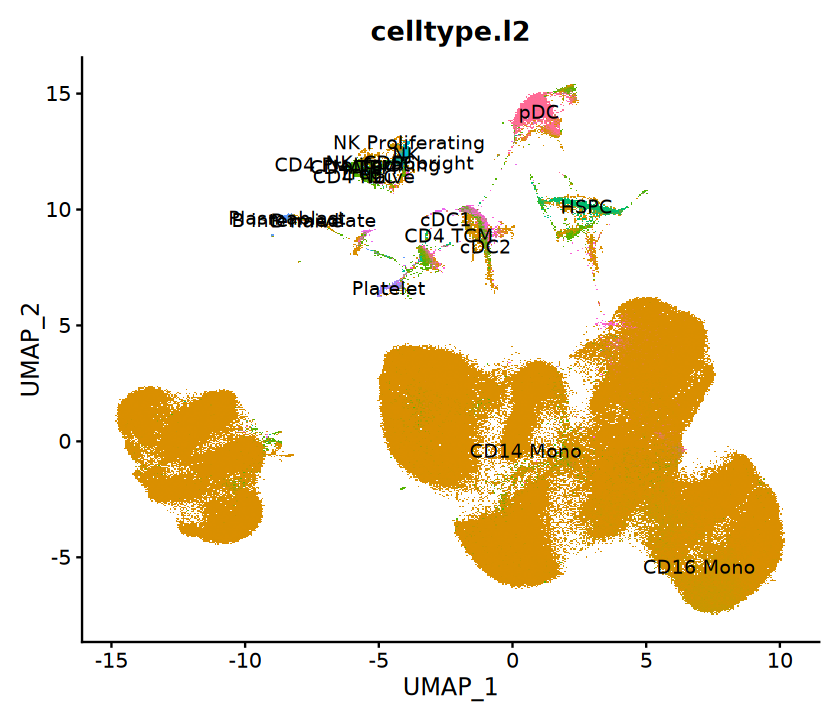

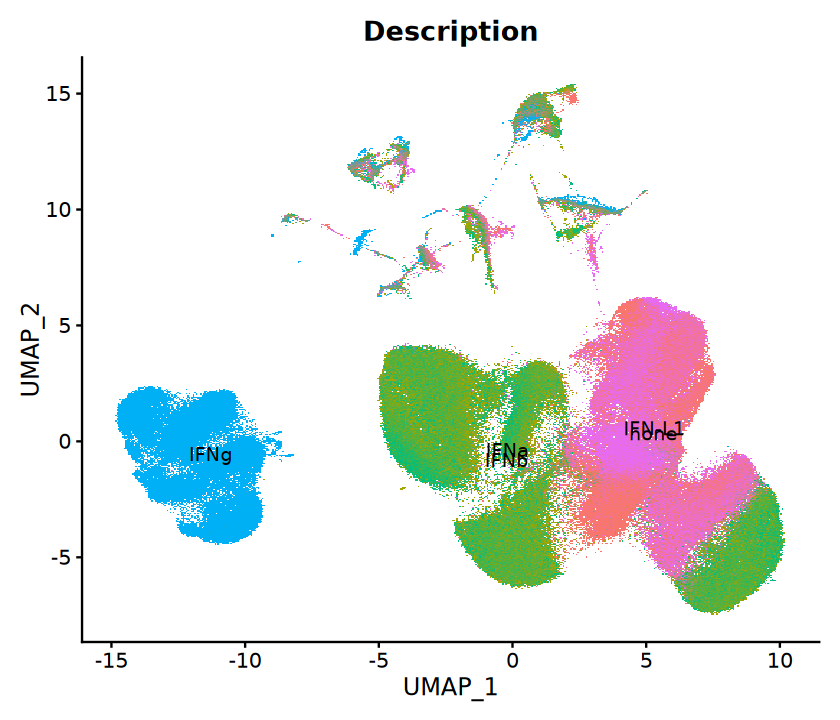

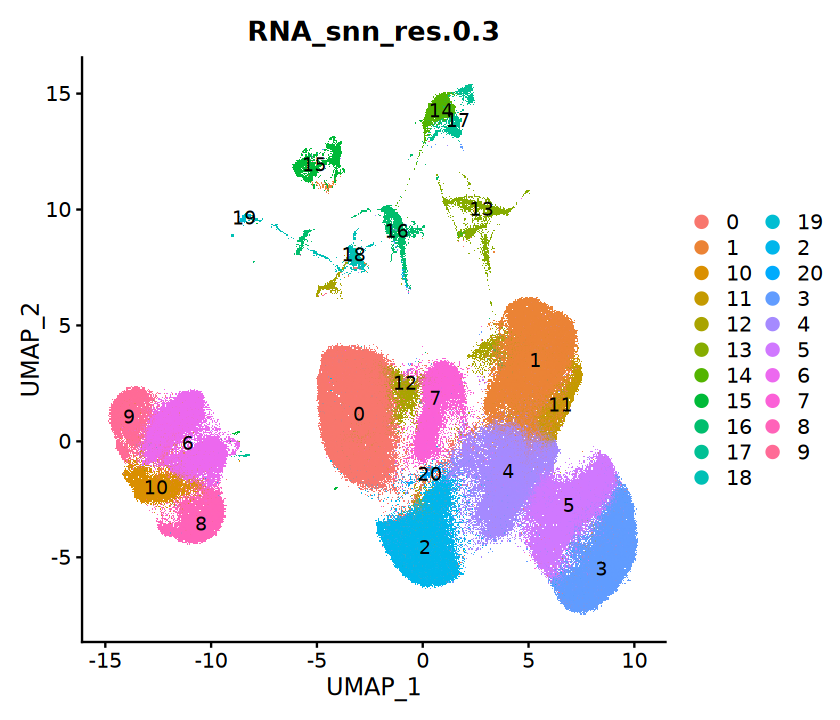

In [ ]:
fig.size(6,7)
DimPlot(so, group.by = "celltype.l2", label = T, raster = T) + theme(legend.position = "none")
DimPlot(so, group.by = "Description", label = T, raster = T) + theme(legend.position = "none")
DimPlot(so, group.by = "RNA_snn_res.0.3", label = T, raster = T) 

In [ ]:
prop_df <- so@meta.data %>%
  count(RNA_snn_res.0.3, celltype.l2) %>%
  group_by(RNA_snn_res.0.3) %>%
  mutate(percent = 100 * n / sum(n)) %>%
  ungroup()

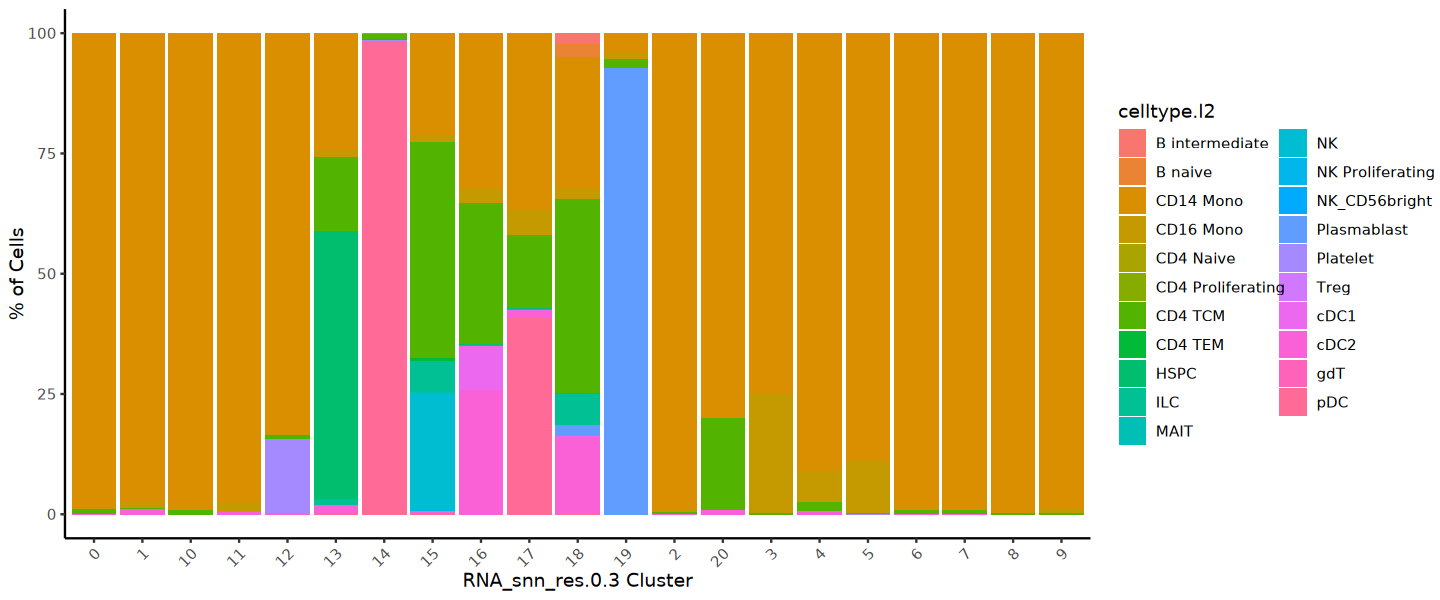

In [51]:
fig.size(5,12)
ggplot(prop_df, aes(x = RNA_snn_res.0.3, y = percent, fill = celltype.l2)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(
    x = "RNA_snn_res.0.3 Cluster",
    y = "% of Cells",
  ) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [50]:
table(so$RNA_snn_res.0.3, so$celltype.l2)

    
     B intermediate B naive CD14 Mono CD16 Mono CD4 Naive CD4 Proliferating
  0               0       0     55381       281         0                 0
  1               0       0     40942       512         0                 0
  10              0       0      7645        15         0                 0
  11              0       0      5421       116         0                 0
  12              0       0      4184        10         0                 0
  13              0       1       997        65         0                 0
  14              0       2         7         1         0                 0
  15              0       0       761        51         5                 1
  16              0       0      1137       103         0                 0
  17              0       1       791       112         0                 0
  18             48      58       576        43         0                 0
  19              0       0        25         7         0                 0
  2    

In [ ]:
# remove contaminating cell clusters
sub <- so %>% 
        subset(RNA_snn_res.0.3 %ni% c(13,14,15,16,17,18,19))

In [11]:
# clean metadata
cols_keep <- c("n_reads", "n_umis", "nFeature_RNA", "barcodes", "original_barcodes", "pool_id", "sampleID", 
               "batch_id", "cell_uuid", "celltype.l1", "celltype.l2", "DonorID", "Stim")
sub$Stim <- sub$Description
sub@meta.data[, cols_keep] <- sub@meta.data[, cols_keep] 

In [42]:
sub %>% saveRDS(file.path(wd, "seurat_objects", "celltype_objects", "Cleaned", glue("{celltype}_so_cleaned.rds")))

In [ ]:
### Save as H5AD 

In [44]:
SaveH5Seurat(sub, file.path(wd, "h5ad", glue("{celltype}.h5seurat")))

Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA

Adding data for RNA

Adding scale.data for RNA

Adding variable features for RNA

Adding feature-level metadata for RNA

Adding cell embeddings for pca

Adding loadings for pca

No projected loadings for pca

Adding standard deviations for pca

No JackStraw data for pca

Adding cell embeddings for umap

No loadings for umap

No projected loadings for umap

No standard deviations for umap

No JackStraw data for umap



In [45]:
Convert(file.path(wd, "h5ad", glue("{celltype}.h5seurat")), dest = "h5ad")

Validating h5Seurat file

Adding scale.data from RNA as X

Transfering meta.features to var

Adding data from RNA as raw

Transfering meta.features to raw/var

Transfering meta.data to obs

Adding dimensional reduction information for pca

Adding feature loadings for pca

Adding dimensional reduction information for umap



In [5]:
sub <- readRDS(file.path(wd, "seurat_objects", "celltype_objects", "Clean", glue("{celltype}_so_cleaned_v1.rds")))

### Inspect doublets

In [6]:
doublets <- fread(file.path(wd, "Scrublet", "scrublet_doublet_calls.csv"))

In [7]:
sub@meta.data <- sub@meta.data %>% 
                    left_join(doublets %>% select(barcode, predicted_doublet), by = c("barcodes" = "barcode"))
rownames(sub@meta.data) <- sub$barcodes

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



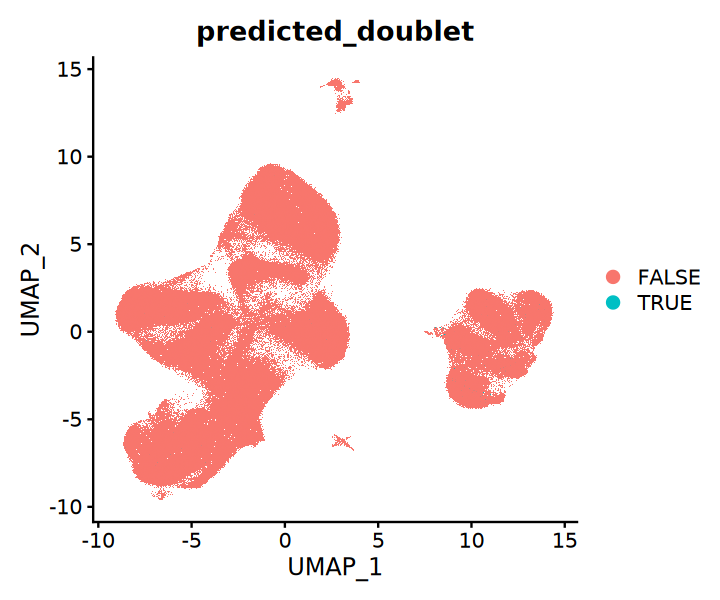

In [8]:
fig.size(5,6)
DimPlot(sub, group.by = "predicted_doublet")

In [10]:
table(sub$sampleID, 
      sub$predicted_doublet)

              
               FALSE  TRUE
  FIX00055     15454     1
  FIX00056     16016     6
  FIX00057     16948     0
  FIX00058      9910    16
  FIX00059     12984     3
  FIX00121     10463     4
  FIX00122     21310     2
  FIX00123     16569     2
  FIX00124     14193     6
  FIX00125     11965     7
  FIX00161     12688     2
  FIX00162      9290     0
  FIX00163     11934     1
  FIX00164     11379    16
  FIX00165      8767     1
  FIX04861-007 12712     1
  FIX04861-008 17403     3
  FIX04861-009 14565     1
  FIX04861-010 12960    25
  FIX04861-011 13963     0
  FIX04862-022  1137     0
  FIX04862-023  8855     0
  FIX04862-024  8400     0
  FIX04862-025  7870    23
  FIX04862-026  6252     1

In [76]:
sub %>% 
    subset(predicted_doublet == FALSE) %>%
    saveRDS(file.path(wd, "seurat_objects", "celltype_objects", glue("{celltype}_so_cleaned_v2.rds")))

## B cells

In [11]:
celltype <- "Bcell"

In [47]:
so <- readRDS(file.path(wd, "seurat_objects", "celltype_objects", glue("{celltype}_so.rds")))

#### Remove contaminating cell types + recluster

In [ ]:
so <- so %>% FindClusters(resolution = 0.3)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



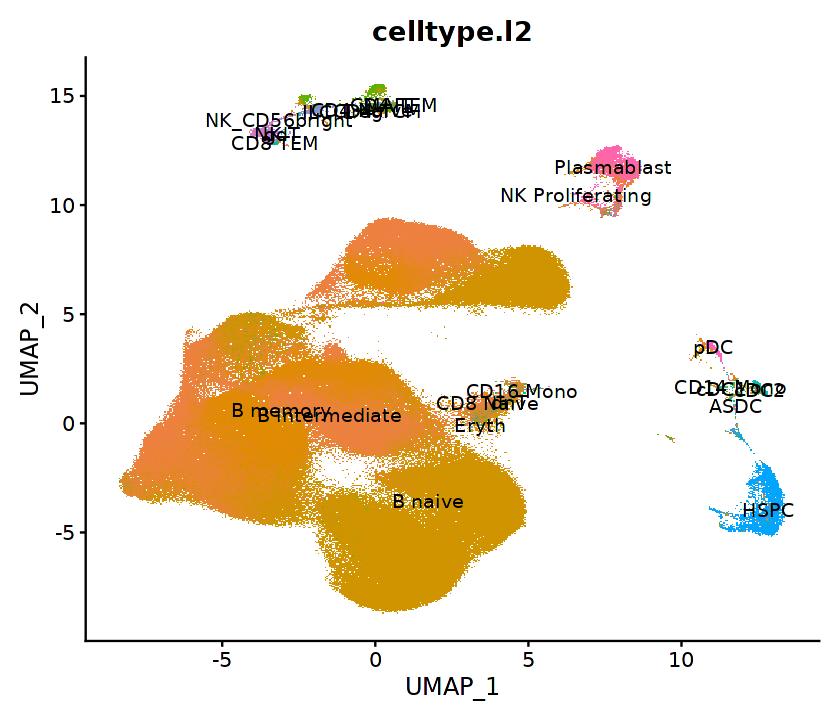

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



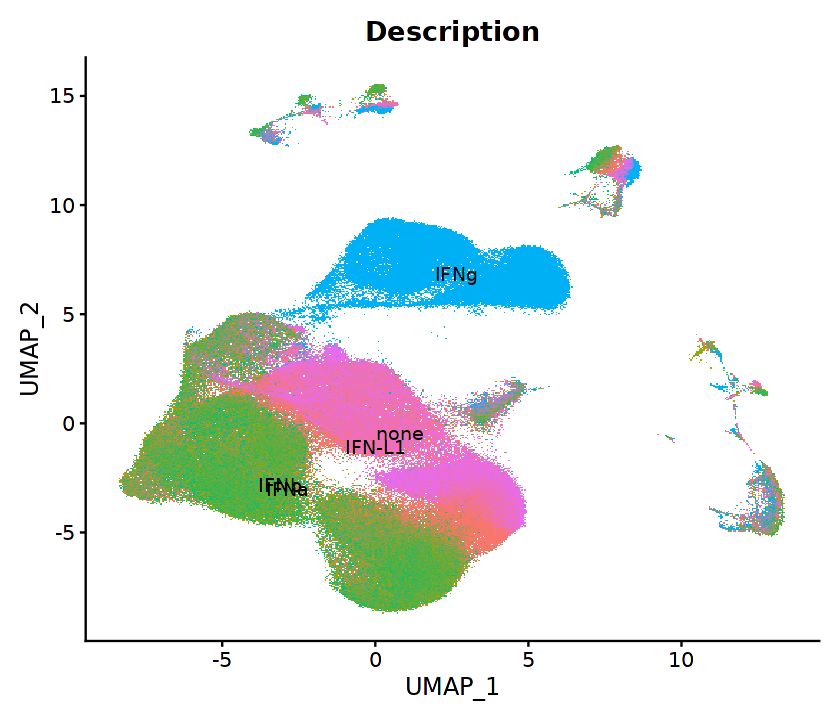

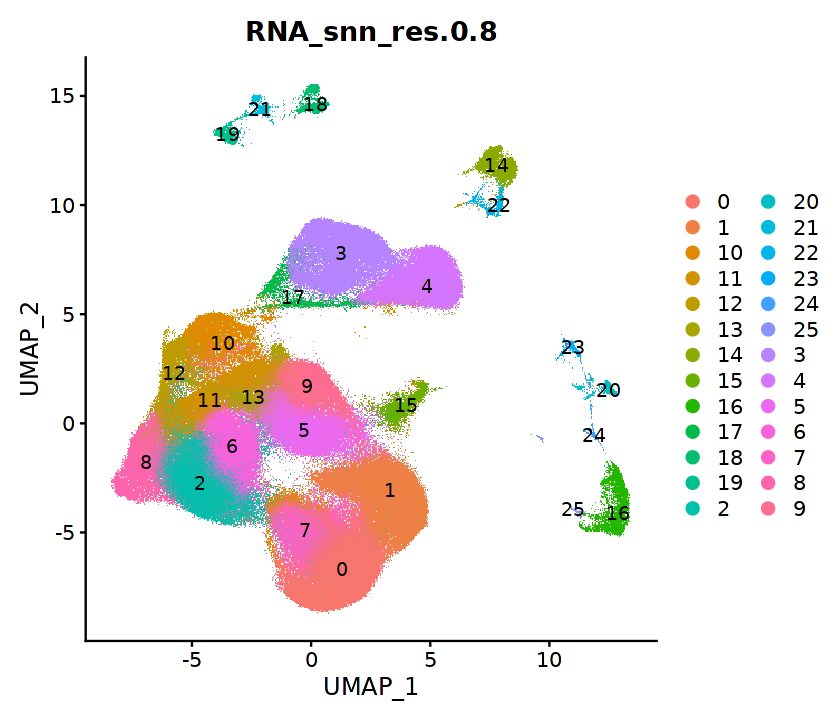

In [112]:
fig.size(6,7)
DimPlot(so, group.by = "celltype.l2", label = T, raster = T) + theme(legend.position = "none")
DimPlot(so, group.by = "Description", label = T, raster = T) + theme(legend.position = "none")
DimPlot(so, group.by = "RNA_snn_res.0.8", label = T, raster = T) 

In [113]:
sub <- so %>% subset(RNA_snn_res.0.8 %ni% c(15,18,19,21,20,16,23,24,25))
sub <- sub %>%
            RunUMAP(dims = 1:30) %>%
            FindNeighbors(dims = 1:30) %>%
            FindClusters(resolution = 0.3, verbose = FALSE)
            

18:52:28 UMAP embedding parameters a = 0.9922 b = 1.112

18:52:28 Read 291537 rows and found 30 numeric columns

18:52:28 Using Annoy for neighbor search, n_neighbors = 30

18:52:28 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:53:18 Writing NN index file to temp file /tmp/RtmpSXmA2C/file63d46d76618d

18:53:18 Searching Annoy index using 1 thread, search_k = 3000

18:55:40 Annoy recall = 100%

18:55:44 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

18:55:55 Initializing from normalized Laplacian + noise (using irlba)

18:56:19 Commencing optimization for 200 epochs, with 13382508 positive edges

18:59:16 Optimization finished

Computing nearest neighbor graph

Computing SNN



In [128]:
sub <- sub %>% FindClusters(resolution = 0.8)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 291537
Number of edges: 6726119

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8826
Number of communities: 27
Elapsed time: 384 seconds


7 singletons identified. 20 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



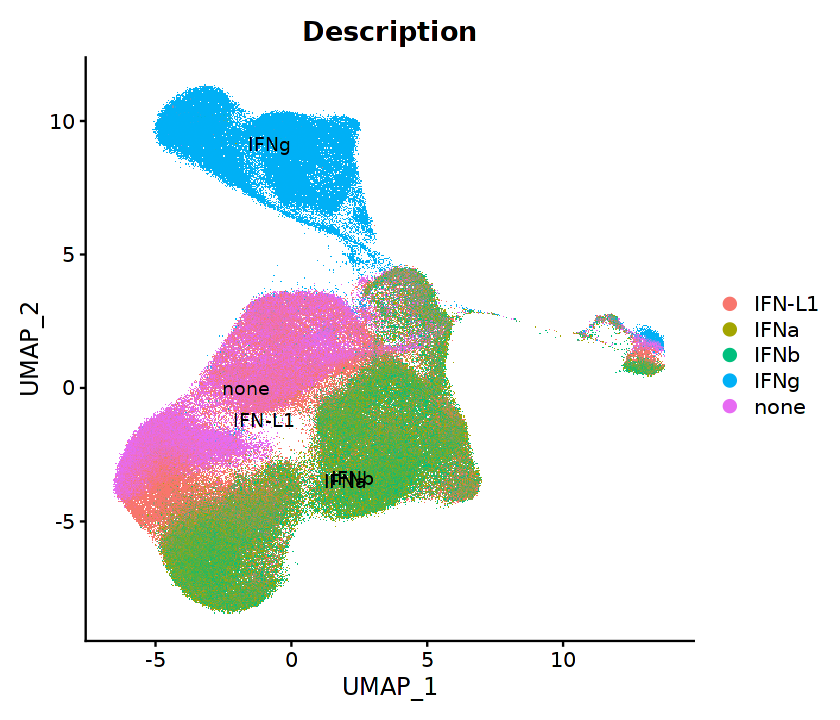

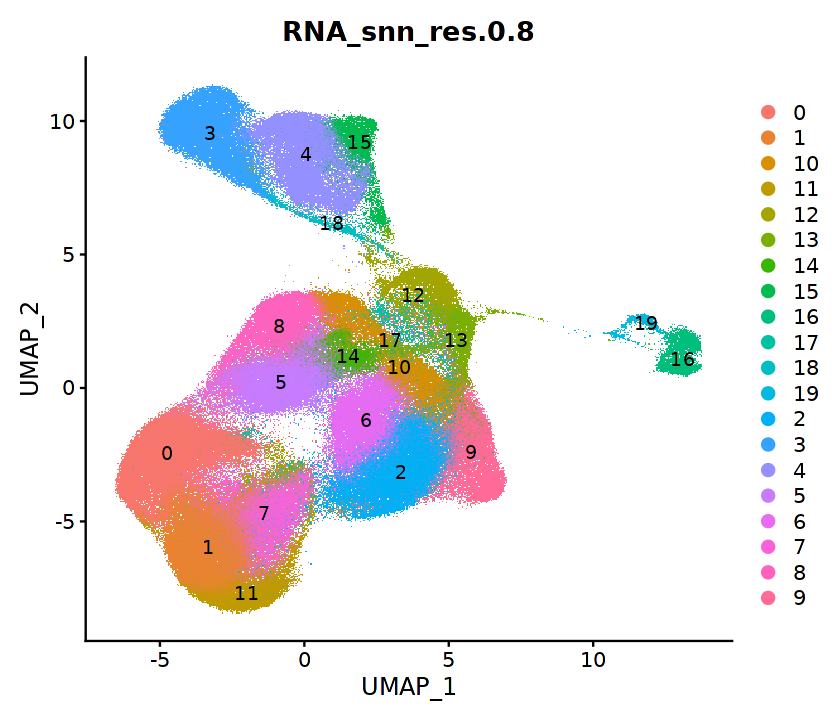

In [130]:
fig.size(6,7)
DimPlot(sub, group.by = "Description", label = T, raster = T) 
DimPlot(sub, group.by = "RNA_snn_res.0.8", label = T, raster = T) 

In [126]:
genes <- c("AIM2", "CD27", "ITGAX", "IGHM", "IGHA1", "IGHA2", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "TBX21",
            "CD19", "CD38", "CD24", "PDCD1", "YBX3", "TBET", "CD38", "MZB1", "CD9", "IL4A", "PRDM1", "CR2", "MS4A1", "CD10")

Warning message in FetchData.Seurat(object = object, vars = c(dims, "ident", features), :
“The following requested variables were not found: IGHG2, IGHG4, TBET, IL4A, CD10”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FAL

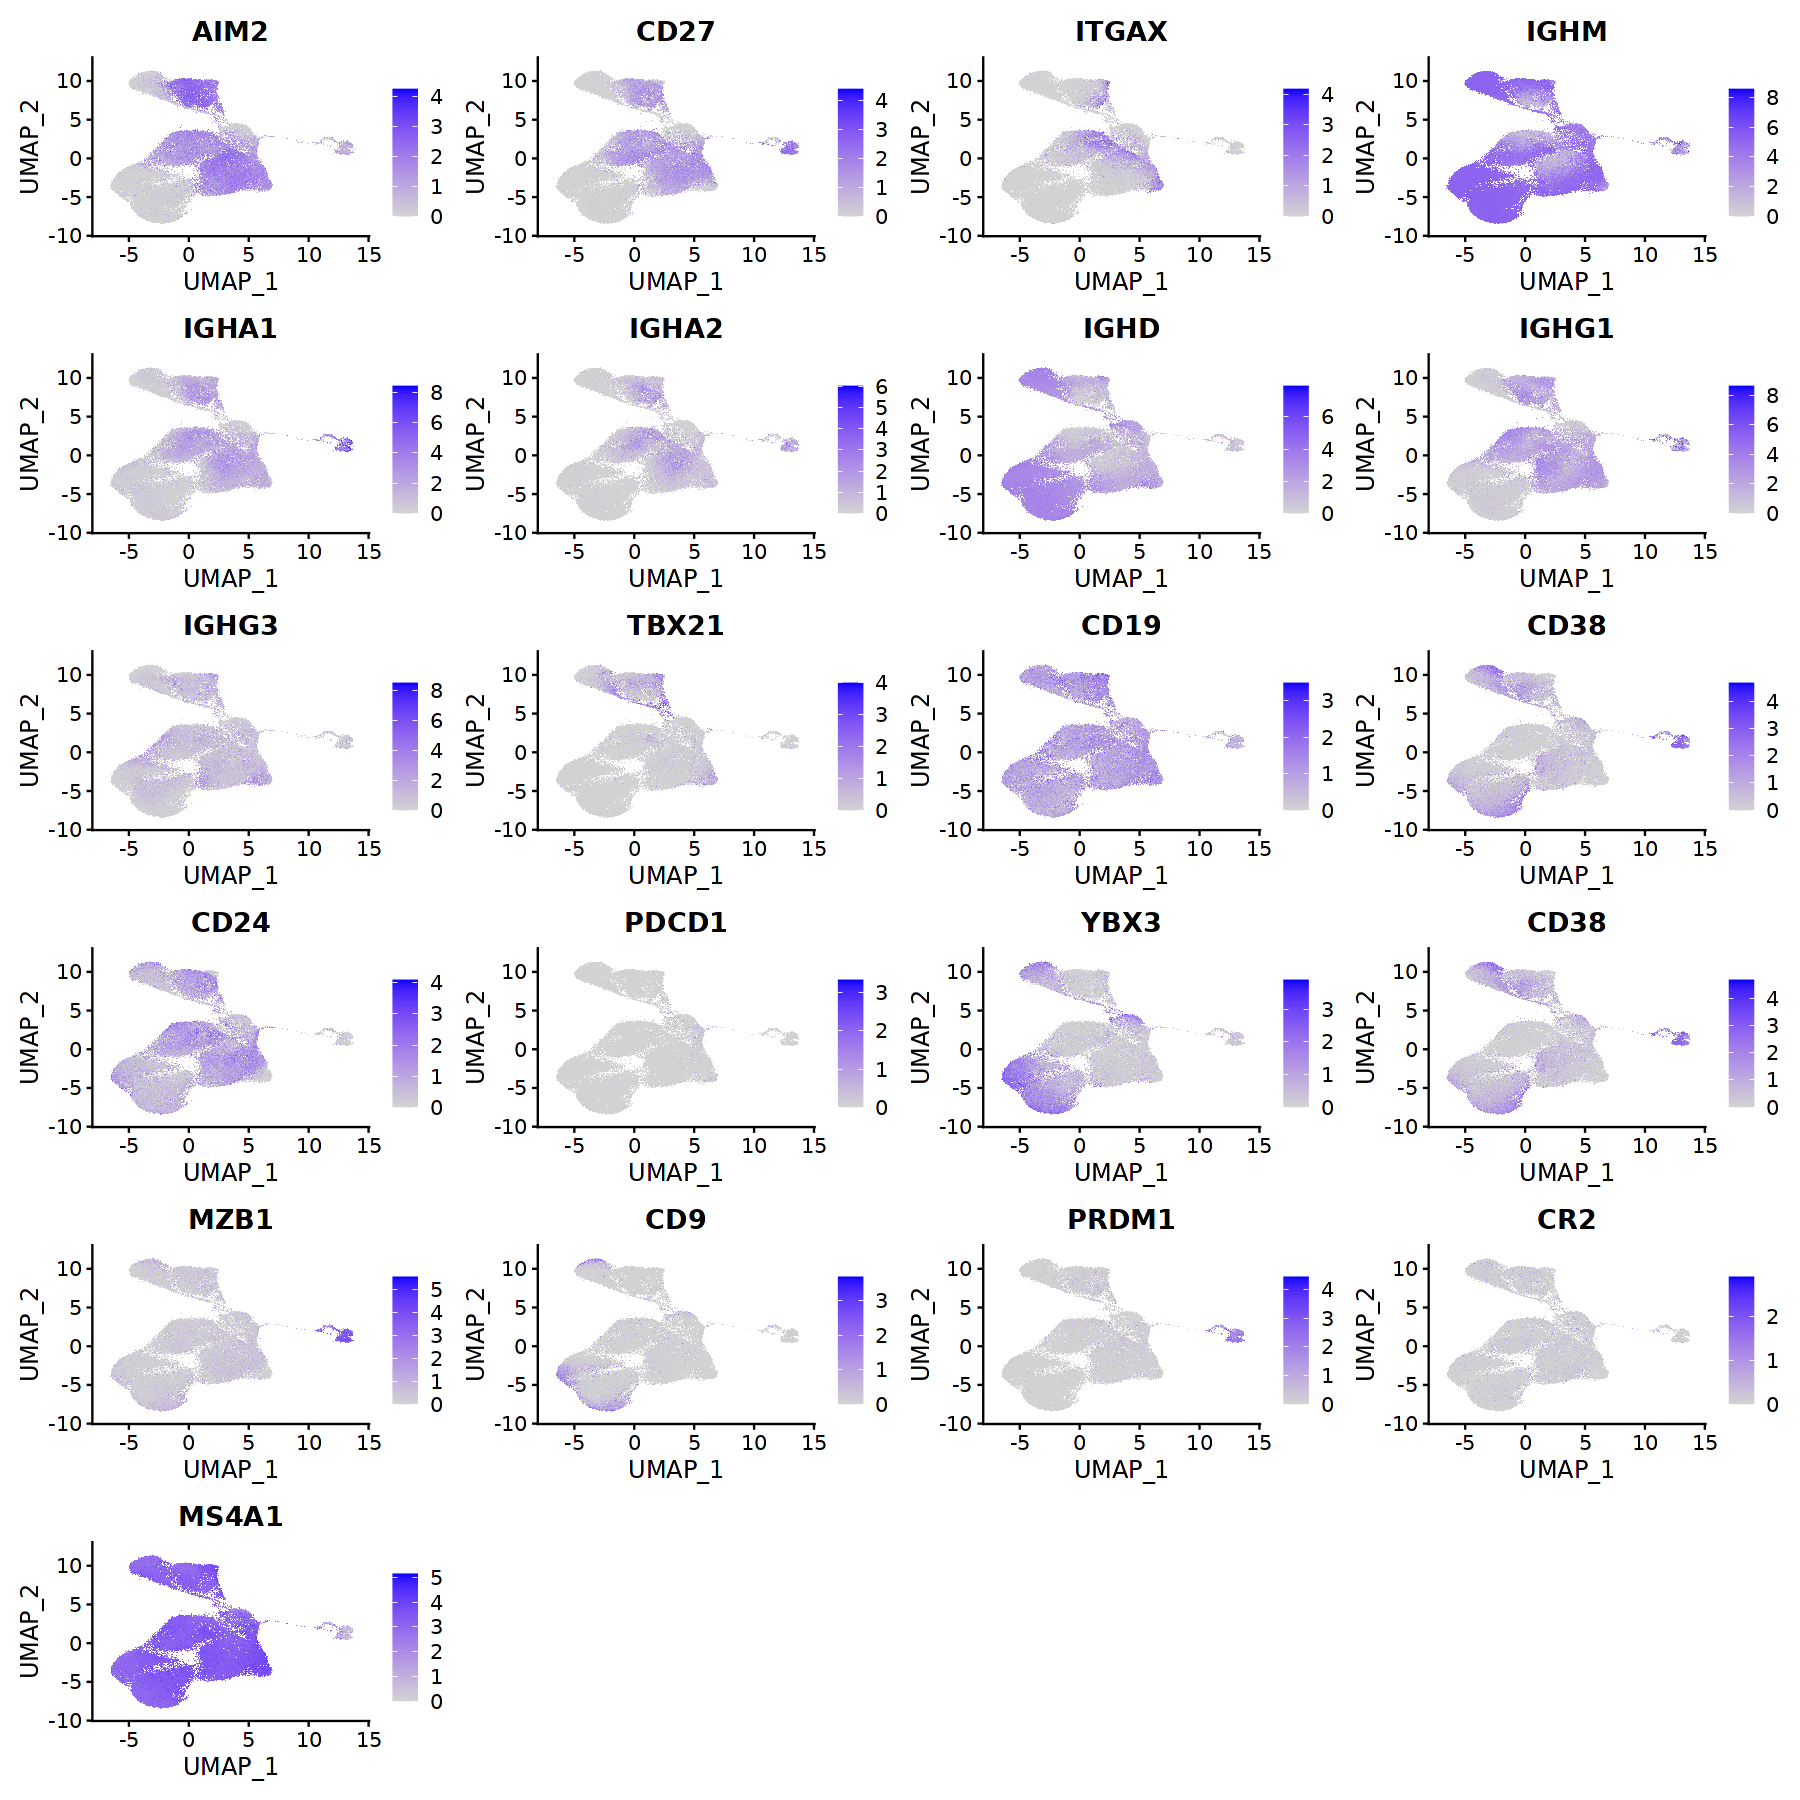

In [127]:
fig.size(15,15)
FeaturePlot(sub, features = genes, raster = T)

`summarise()` has grouped output by 'gene'. You can override using the
`.groups` argument.


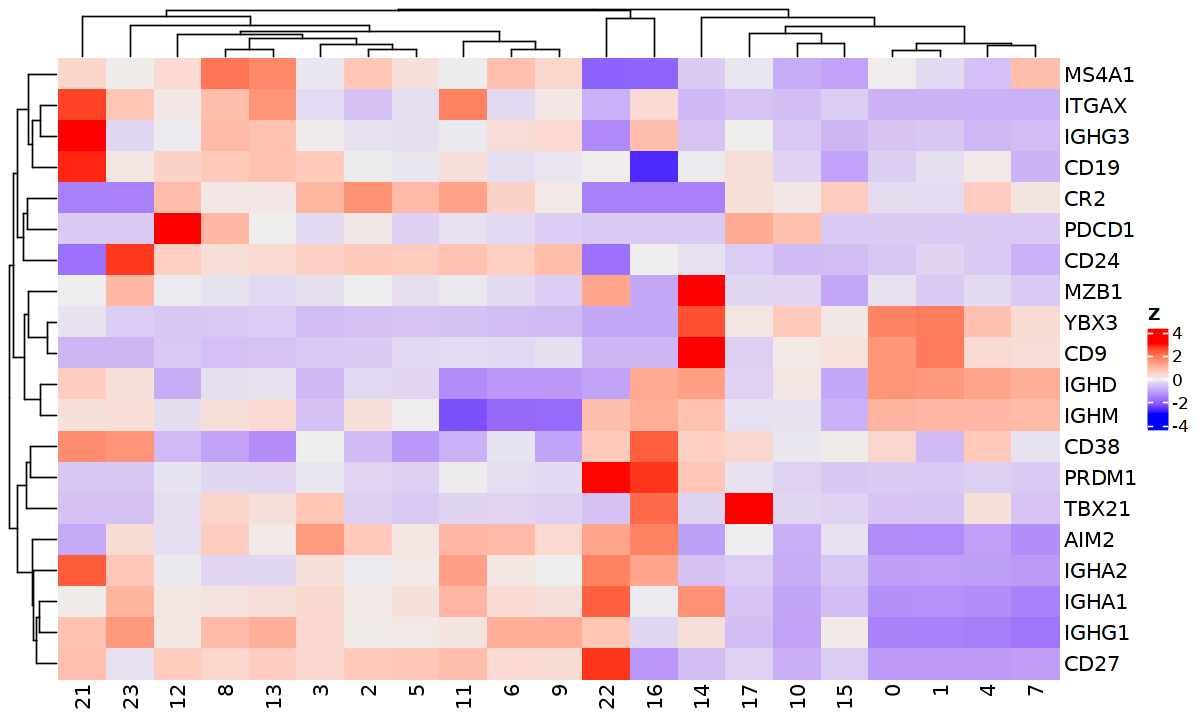

In [75]:
fig.size(6,10)
heatmap(sub, features = genes,
       group_by = 'RNA_snn_res.0.8', scale = T, method = "mean") 


In [ ]:
sub$celltype.l2 <- case_when(sub$RNA_snn_res.0.8 %in% c(3,0,1,7,11) ~ "Naive",
                            sub$RNA_snn_res.0.8 %in% c(4,15,18,2,5,6,8,9,10,12,13,14,17) ~ "Memory",
                            sub$RNA_snn_res.0.8 %in% c(16,19) ~ "Plasma")

In [ ]:
# clean metadata
cols_keep <- c("n_reads", "n_umis", "nFeature_RNA", "barcodes", "original_barcodes", "pool_id", "sampleID", 
               "batch_id", "cell_uuid", "celltype.l1", "celltype.l2", "DonorID", "Stim")
sub$Stim <- sub$Description
sub@meta.data[, cols_keep] <- sub@meta.data[, cols_keep] 

In [ ]:
sub %>% saveRDS(file.path(wd, "seurat_objects", "celltype_objects", "Cleaned", glue("{celltype}_so_cleaned_v1.rds")))

In [ ]:
### Save as H5AD 

In [50]:
SaveH5Seurat(sub, file.path(wd, "h5ad", glue("{celltype}.h5seurat")))

Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA

Adding data for RNA

Adding scale.data for RNA

Adding variable features for RNA

Adding feature-level metadata for RNA

Adding cell embeddings for pca

Adding loadings for pca

No projected loadings for pca

Adding standard deviations for pca

No JackStraw data for pca

Adding cell embeddings for umap

No loadings for umap

No projected loadings for umap

No standard deviations for umap

No JackStraw data for umap



In [51]:
Convert(file.path(wd, "h5ad", glue("{celltype}.h5seurat")), dest = "h5ad")

Validating h5Seurat file

Adding scale.data from RNA as X

Transfering meta.features to var

Adding data from RNA as raw

Transfering meta.features to raw/var

Transfering meta.data to obs

Adding dimensional reduction information for pca

Adding feature loadings for pca

Adding dimensional reduction information for umap

Adding RNA_snn as neighbors



### Inspect doublets

In [13]:
doublets <- fread(file.path(wd, "Scrublet", "scrublet_doublet_calls.csv"))

In [14]:
sub@meta.data <- sub@meta.data %>% 
                    left_join(doublets %>% select(barcode, predicted_doublet), by = c("barcodes" = "barcode"))
rownames(sub@meta.data) <- sub$barcodes

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



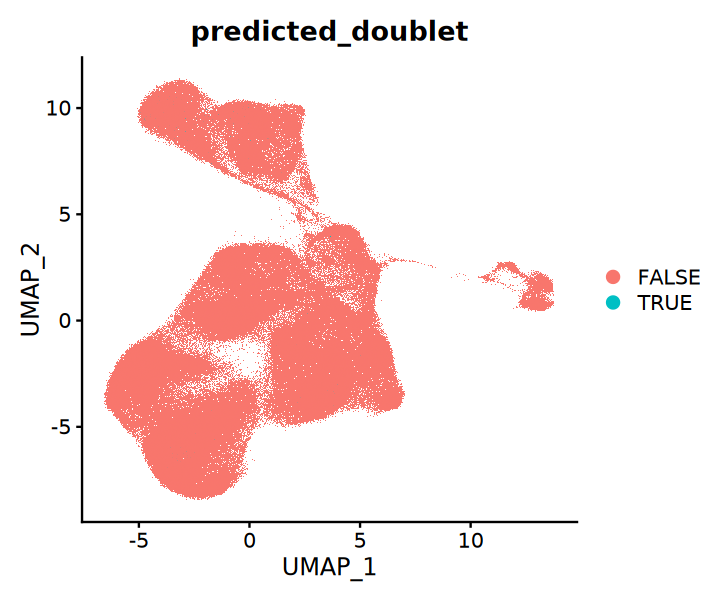

In [15]:
fig.size(5,6)
DimPlot(sub, group.by = "predicted_doublet")

In [16]:
table(sub$sampleID, 
      sub$predicted_doublet)

              
               FALSE  TRUE
  FIX00074     12002     0
  FIX00075     13069     1
  FIX00076     18913    36
  FIX00077     15625     7
  FIX00078     14847     7
  FIX00140      8998     0
  FIX00141     11704     0
  FIX00142     10325     0
  FIX00143     11675     8
  FIX00144      8705     0
  FIX00180     10715     0
  FIX00181     14158     0
  FIX00182     14362     0
  FIX00184     13967     0
  FIX00239      8802    24
  FIX04861-026 11094     0
  FIX04861-027 11292     0
  FIX04861-028 10527     0
  FIX04861-029 11465    20
  FIX04861-030 10648     2
  FIX04862-004  9656     0
  FIX04862-005  9701     0
  FIX04862-006  9887     1
  FIX04862-007  8338     3
  FIX04862-008 10952     1

## T cell + NK objects (from Tao)

In [ ]:
# Download T and NK seurat objects from Tao
# T cell object split into two by alpha/beta and gamma/lambda stims 
files <- list("1bd57b29-5405-456a-9ea5-2fd57b59c330", 
              "b279d599-abc0-4603-8f01-1e07e9c7725c", 
              "9132ed3b-9132-4125-9e09-9ff9f8a13bcc")
cacheFiles(files)

### T cell

In [13]:
celltype <- "Tcell"

In [14]:
so1 <- readRDS(file.path(wd, "seurat_objects", "IFN_AB_30T_v2_231108_for_NM.rds"))
so2 <- readRDS(file.path(wd, "seurat_objects", "IFN_GL_30T_v2_231108_for_NM.rds"))
so_merged <- merge(so1, so2 %>% subset(condition1 != "ctrl"))

In [15]:
### clean-up variable naming
so_merged$batch <- so_merged$batch %>% stringr::str_extract("D\\d+")
so_merged$DonorID <- recode(so_merged$batch,
                      "D1" = "3955BW",
                      "D2" = "3283BW",
                      "D3" = "2616BW",
                      "D4" = "6811BW",
                      "D5" = "3491BW")

so_merged$Description <- recode(so_merged$condition1,
                        "IFNA" = "IFNa",
                        "IFNB" = "IFNb",
                        "IFNG" = "IFNg",
                        "IFNL" = "IFN-L1",
                        "ctrl" = "none")


In [20]:
# clean-up metadata column names
so_merged$Celltype <- celltype
so_merged$celltype.l1 <- celltype
so_merged$celltype.l2 <- so_merged$Tcellsubset

In [24]:
# merge with metadata sheet
so_merged$BatchID <- so_merged$batch_id %>% stringr::str_sub(1,9)
so_merged@meta.data <- so_merged@meta.data %>% left_join(meta %>% select(SampleID, BatchID, DonorID, Celltype, Description),
                          by = c("BatchID", "DonorID", "Celltype", "Description"))

In [30]:
so_merged@meta.data <- so_merged@meta.data %>% dplyr::rename(
                              "nFeature_RNA" = "nFeaturess_RNA")

In [31]:
# filter metadata
cols_keep <- c("n_reads", "n_umis", "nFeature_RNA", "barcodes", "original_barcodes", "pool_id", "sampleID", 
               "batch_id", "cell_uuid", "celltype.l1", "celltype.l2", "DonorID", "Stim")
so_merged$Stim <- so_merged$Description
so_merged@meta.data[, cols_keep] <- so_merged@meta.data[, cols_keep]

In [ ]:
# remove CD4 CTL and save cleaned version
so_merged  %>% subset(celltype.l2 != "CD4 CTL") %>%
    saveRDS(file.path(wd, "seurat_objects", "celltype_objects", "Cleaned", glue("{celltype}_so_cleaned_v1.rds")))

In [ ]:
# save H5AD objects

In [32]:
SaveH5Seurat(so_merged, file.path(wd, "h5ad", glue("{celltype}_so_cleaned.h5seurat")))

Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA

Adding data for RNA

No variable features found for RNA

No feature-level metadata found for RNA



In [33]:
Convert(file.path(wd, "h5ad", glue("{celltype}_so_cleaned.h5seurat")), dest = "h5ad")

Validating h5Seurat file

Adding data from RNA as X

Adding counts from RNA as raw

Transfering meta.data to obs



### NK

In [ ]:
### clean metadata

In [35]:
celltype <- "NK"

In [36]:
so <- readRDS(file.path(wd, "cache/9132ed3b-9132-4125-9e09-9ff9f8a13bcc/IFN_25NK_v2_231108_for_NM.rds"))

In [37]:
# recode donor (batch) and stim metadata
so$DonorID <- recode(so$batchID,
                      "batch1" = "3955BW",
                      "batch2" = "3283BW",
                      "batch4" = "2616BW",
                      "batch5" = "6811BW",
                      "batch6" = "3491BW")

so$Description <- recode(so$condition1,
                        "IFNA" = "IFNa",
                        "IFNB" = "IFNb",
                        "IFNG" = "IFNg",
                        "IFNL" = "IFN-L1",
                        "ctrl" = "none")

In [38]:
# fix column names
so$Celltype <- celltype
so$celltype.l1 <- celltype
so$celltype.l2 <- so$nksubset
so$BatchID <- so$batch_id %>% substr(1, 9)

In [45]:
# merged with metadata
so@meta.data <- so@meta.data %>% left_join(meta %>% select(SampleID, BatchID, DonorID, Celltype, Description),
                          by = c("BatchID", "DonorID", "Celltype", "Description"))

In [50]:
so@meta.data <- so@meta.data %>% dplyr::rename(
                           "nFeature_RNA" = "nFeaturess_RNA")

In [52]:
# filter metadata columns
cols_keep <- c("n_reads", "n_umis", "nFeature_RNA", "barcodes", "original_barcodes", "pool_id", "sampleID", 
               "batch_id", "cell_uuid", "celltype.l1", "celltype.l2", "DonorID", "Stim")
so@meta.data[, cols_keep] <- so@meta.data[, cols_keep] 

In [ ]:
### save seurat object and H5AD

In [53]:
so %>% saveRDS(file.path(wd, "seurat_objects", "celltype_objects", "Cleaned", glue("{celltype}_so_cleaned_v1.rds")))

In [42]:
SaveH5Seurat(so, file.path(wd, "h5ad", glue("{celltype}_so_cleaned.h5seurat")))

Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA

Adding data for RNA

No variable features found for RNA

Adding feature-level metadata for RNA



In [43]:
Convert(file.path(wd, "h5ad", glue("{celltype}_so_cleaned.h5seurat")), dest = "h5ad")

Validating h5Seurat file

Adding data from RNA as X

Transfering meta.features to var

Adding counts from RNA as raw

Transfering meta.features to raw/var

Transfering meta.data to obs



## Generate downsampled combined celltype/stim object

In [6]:
l1_celltypes <- c("Monocyte", "Bcell", "Tcell", "NK")

In [7]:
so_list <- lapply(l1_celltypes[1], function(c){
    readRDS(file.path(wd, "seurat_objects", "celltype_objects", "Cleaned", glue("{c}_so_cleaned_v1.rds")))
    })

so <- merge(so_list[[1]], so_list[2:length(so_list)])

In [ ]:
Idents(so) <- "sampleID"
so_sampled <- so %>% 
                subset(downsample = 5000) %>%
                FindVariableFeatures()

In [ ]:
variable_genes <- VariableFeatures(so_sampled)
so[variable_genes,] %>% saveRDS(file.path(wd, "seurat_objects", glue("so_complete2.rds")))

## Upload 

### Seurat objects

In [17]:
study_space_uuid <- '66e4468f-7c2e-4fbf-8029-7b75e2ca911b'
title <- paste0("CertPro Analysis Result ", Sys.Date())

In [18]:
out_files <- list.files(file.path(wd, "seurat_objects", "celltype_objects", "Cleaned"), full.names = T) 

In [ ]:
uploadFiles(
    studySpaceId = study_space_uuid,
    title = title,
    files = as.list(out_files),
    inputFileIds = file_uuid
)

### H5ADs

In [23]:
study_space_uuid <- '66e4468f-7c2e-4fbf-8029-7b75e2ca911b'
title <- paste0("CertPro Analysis Upload h5ad Celltype Objs", Sys.Date())

In [24]:
out_files <- list.files(file.path(wd, "h5ad"), full.names = T) %>% 
                grep("cleaned", ., value = T)

In [25]:
out_files

[1] "/home/jupyter/h5ad/Bcell_so_cleaned.h5ad"   
[2] "/home/jupyter/h5ad/Monocyte_so_cleaned.h5ad"
[3] "/home/jupyter/h5ad/NK_so_cleaned.h5ad"      
[4] "/home/jupyter/h5ad/Tcell_so_cleaned.h5ad"

In [26]:
uploadFiles(
    studySpaceId = study_space_uuid,
    title = title,
    files = as.list(out_files),
    inputFileIds = file_uuid
)

[1] "Cannot determine the current notebook."
[1] "1) /home/jupyter/notebooks/IFN_object_setup.ipynb"
[1] "2) /home/jupyter/notebooks/scRNA_exploration_app_object_creation_scanpy.ipynb"
[1] "3) /home/jupyter/Untitled.ipynb"


Please select (1-3)  1


You are trying to upload the following files:  /home/jupyter/h5ad/Bcell_so_cleaned.h5ad /home/jupyter/h5ad/Monocyte_so_cleaned.h5ad /home/jupyter/h5ad/NK_so_cleaned.h5ad /home/jupyter/h5ad/Tcell_so_cleaned.h5ad



(y/n) y


$files
$files[[1]]
[1] "/home/jupyter/h5ad/Bcell_so_cleaned.h5ad"

$files[[2]]
[1] "/home/jupyter/h5ad/Monocyte_so_cleaned.h5ad"

$files[[3]]
[1] "/home/jupyter/h5ad/NK_so_cleaned.h5ad"

$files[[4]]
[1] "/home/jupyter/h5ad/Tcell_so_cleaned.h5ad"


$traceId
[1] "b4fbb7c6-30ba-4e7b-a646-92e046ac937b"